In [21]:
# !pip install numpy
# !pip install pandas
# !pip install joblib==1.1.1
# !pip install plotly==2.2.2
# !pip install matplotlib==3.9.0
# !pip install scikit_learn
# !pip install seaborn==0.13.2
# !pip install streamlit==1.34.0

In [26]:
# import library
import numpy as np # linear algebra
import pandas as pd
import joblib
from sklearn.preprocessing import MinMaxScaler
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
# import plotly
# import streamlit

In [28]:
print('joblib: '+joblib.__version__)
print('matplotlib :'+matplotlib.__version__)
print('numpy: '+np.__version__)
print('pandas :'+pd.__version__)
print('plotly :'+pd.__version__)
print('sklearn: '+sklearn.__version__)
print('seaborn :'+sns.__version__)
# print('streamlit :'+streamlit.__version__)

joblib: 1.5.3
matplotlib :3.10.8
numpy: 2.4.4
pandas :3.0.2
plotly :3.0.2
sklearn: 1.8.0
seaborn :0.13.2


# EDA

In [29]:
#load data
df_titanic = pd.read_csv('titanic.csv')

In [30]:
df_titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Descriptive

In [31]:
df_titanic.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [32]:
df_titanic.shape

(891, 12)

In [33]:
df_titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [34]:
df_titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Visualization

### pie chart

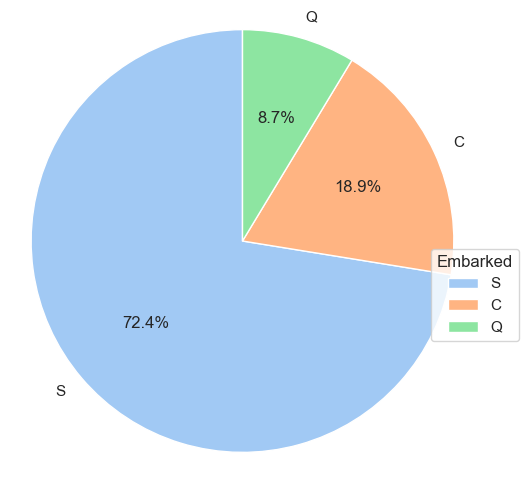

In [35]:
embarked_counts = df_titanic['Embarked'].value_counts()
plt.figure(figsize=(6, 6))
sns.set(style="whitegrid")
plt.pie(embarked_counts, labels=embarked_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.axis('equal')
plt.legend(title='Embarked', loc='upper center' ,bbox_to_anchor=(1, 0.5))
plt.show()

### violin

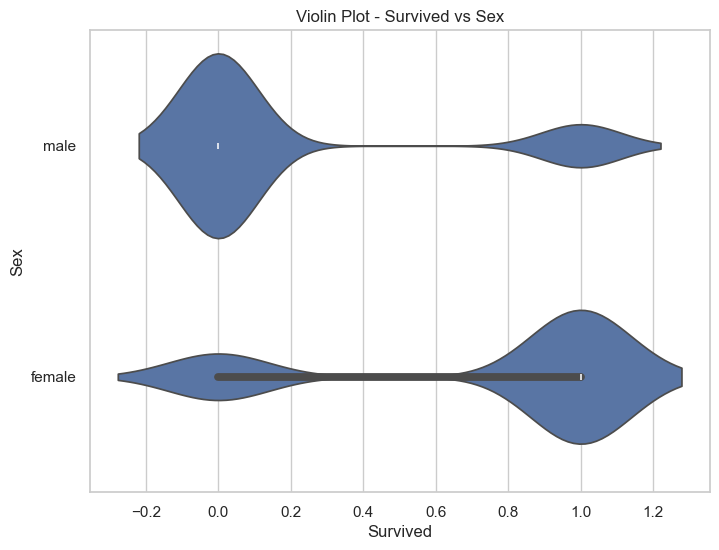

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset Titanic dari seaborn
titanic_data = sns.load_dataset('titanic')

# Membuat chart violin
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_titanic, x='Survived', y='Sex')
plt.title('Violin Plot - Survived vs Sex')
plt.xlabel('Survived')
plt.ylabel('Sex')
plt.show()


### null detection

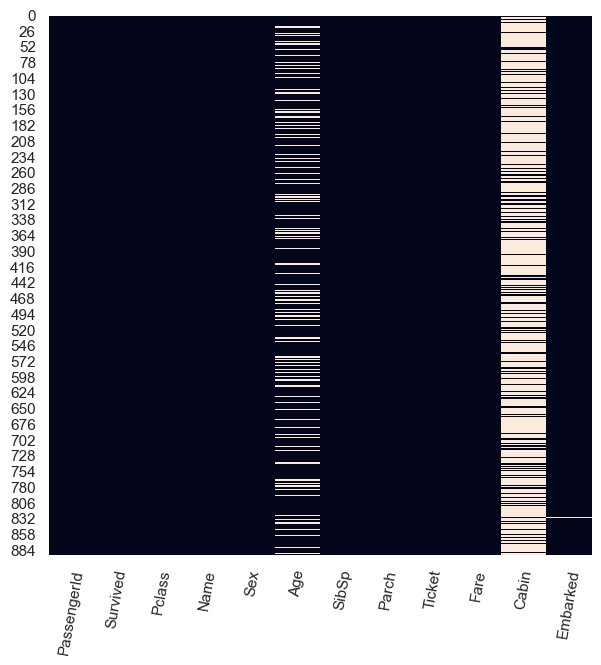

In [37]:
fig, ax = plt.subplots(figsize=(7,7))
sns.heatmap(df_titanic.isnull(), cbar=False)
plt.xticks(rotation=80)
plt.show(fig)

# Modelling

In [38]:
#load data clear
df_clear=pd.read_csv('df_titanic_clear.csv')

In [39]:
df_clear.head()

,Survived,Pclass,Fare_dbscan,Sex_enc,Embarked_enc,Mr,Mrs,Miss,Master,Other,young_adult,adult,elderly,child
0,0,3,7.2500,0,2,1,0,0,0,0,1,0,0,0
1,1,1,71.2833,1,0,0,1,0,0,0,0,1,0,0
2,1,3,7.9250,1,2,0,0,1,0,0,1,0,0,0
3,1,1,53.1000,1,2,0,1,0,0,0,0,1,0,0
4,0,3,8.0500,0,2,1,0,0,0,0,0,1,0,0


In [40]:
# Survived : 0 : dead, 1 : alive
# Pclass : 1 , 2 , 3
# sex_enc : 0 :male, 1:female
# Embarked  0:C, 1:Q , 2:S
# Mr, Mrs, Miss, Other 
#                 'Mlle': 'Miss',
#                  'Mme': 'Miss',
#                  'Ms': 'Miss',
#                  'Dr': 'Mr',
#                  'Major': 'Mr',
#                  'Lady': 'Mrs',
#                  'Countess': 'Mrs',
#                  'Jonkheer': 'Other',
#                  'Col': 'Other',
#                  'Rev': 'Other',
#                  'Capt': 'Mr',
#                  'Sir': 'Mr',
#                  'Don': 'Mr'
                    
# child  : 0-15
# young_adult: 16-30
# adult : 31 -50
# ederly :51-100




## train test split

In [41]:
from sklearn.model_selection import train_test_split

# Memisahkan fitur dan label dari data Anda
X = df_clear.drop('Survived', axis=1)
y = df_clear['Survived']
# Memisahkan data menjadi set pelatihan dan set pengujian
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## create model

In [42]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X, y)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [43]:
feature_importances = model.feature_importances_
fitur=[]
nilai=[]
for feature, importance in zip(X.columns, feature_importances):
    fitur.append(feature)
    nilai.append(importance)
feature_importan= pd.DataFrame({'Fiture':fitur, 'Nilai':nilai})
feature_importan.sort_values(by='Nilai', ascending=False)

,Fiture,Nilai
1,Fare_dbscan,0.405507
2,Sex_enc,0.144104
4,Mr,0.127973
0,Pclass,0.123495
3,Embarked_enc,0.046330
6,Miss,0.044991
5,Mrs,0.037822
12,child,0.016284
10,adult,0.014292
9,young_adult,0.013023


## hyper parameter tuning

In [44]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators': [5,10,50],
               'max_depth': [5,10,20],
               'min_samples_split': [2,5,10],
               'min_samples_leaf': [2,5,10],
               'bootstrap': [False],
                'criterion': ['gini']}
gs = GridSearchCV(model, param_grid=param_grid, cv = 3, verbose=1, n_jobs=-1)
gs.fit(X, y)
print(gs.best_estimator_)

Fitting 3 folds for each of 81 candidates, totalling 243 fits
RandomForestClassifier(bootstrap=False, max_depth=10, min_samples_leaf=2,
                       min_samples_split=10, n_estimators=10)


## accuracy

In [45]:
predictions = gs.best_estimator_.predict(X_test)

In [46]:
actual=y_test

In [47]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score

conf_matrix = confusion_matrix(actual, predictions)

print(conf_matrix)
print('Accuracy score:', round(accuracy_score(actual, predictions),2))
print('Recall score:', round(recall_score(actual, predictions),2))
print('Precision score:', round(precision_score(actual, predictions),2))
print('F1 score:', round(f1_score(actual, predictions),2))

[[95 10]
 [ 9 65]]
Accuracy score: 0.89
Recall score: 0.88
Precision score: 0.87
F1 score: 0.87


## export model

In [53]:
model_rf= RandomForestClassifier(bootstrap=False, max_depth=20, min_samples_leaf=5,
                       min_samples_split=10, n_estimators=50)

In [54]:
model_rf.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [55]:
joblib.dump(model_rf, 'model_rf.joblib')

['model_rf.joblib']

## import model

In [62]:
model_loaded = joblib.load('model_rf.joblib')

In [63]:
X[:1]

,Pclass,Fare_dbscan,Sex_enc,Embarked_enc,Mr,Mrs,Miss,Master,Other,young_adult,adult,elderly,child
0,3,7.25,0,2,1,0,0,0,0,1,0,0,0


In [64]:
y_predict = model_loaded.predict(X[1:2])
y_predict

array([1])

## Probability

In [65]:
pred_prob = model_loaded.predict_proba(X[:1])

In [66]:
pred_prob

array([[0.9525703, 0.0474297]])

In [67]:
pred_prob[0][0]

np.float64(0.9525703021871769)